# Vertically Checked Tilt Analysis

Main summary plots for vertically checked tilt distance.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import seacofs_tilt_tools as tilt

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths)
# df_eddies = tilt.add_time_coordinates(df_eddies)
df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=False)

n_profiles = len(df_eddies)
n_tilt = df_eddies.TiltDis.notna().sum()
print(f"Eddy-days: {n_profiles:,}")
print(f"Tilt-checked eddy-days: {n_tilt:,} ({n_tilt / n_profiles:.1%})")
df_eddies.head()


Eddy-days: 125,226
Tilt-checked eddy-days: 104,459 (83.4%)


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir,Day_idx,norm_time
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,47.992205,1.434563,74.597458,38,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,0,0.000000
1,1,1463,CE,160.982386,-29.745743,260,274,920.121471,1352.093925,-0.000014,...,50.858737,1.417135,76.449111,38,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,1,0.027027
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,53.725269,1.413542,78.300764,38,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,2,0.054054
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,56.591801,1.411879,69.625773,38,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,33.976810,184.917206,3,0.081081
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,57.471319,1.597888,72.613632,38,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,30.067059,181.174121,4,0.108108


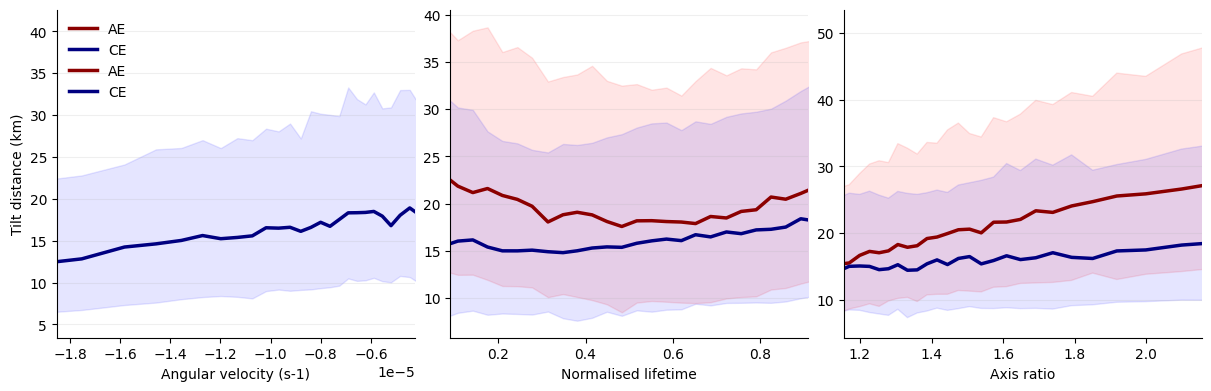

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)

ax = tilt.binned_tilt_panel(axs[0], df_eddies[df_eddies.Cyc=='AE'], "Omega", "", ylabel="Tilt distance (km)")
tilt.binned_tilt_panel(ax, df_eddies[df_eddies.Cyc=='CE'], "Omega", "Angular velocity (s-1)", ylabel="Tilt distance (km)")
tilt.binned_tilt_panel(axs[1], df_eddies, "norm_time", "Normalised lifetime")
tilt.binned_tilt_panel(axs[2], df_eddies, "AR", "Axis ratio")
axs[0].legend(frameon=False)
plt.show()


In [4]:
# season_df = df_eddies.copy()
# if "Date" in season_df.columns:
#     season_df = tilt.add_season(season_df)
#     order = ["DJF", "MAM", "JJA", "SON"]
#     data = [season_df.loc[season_df.Season == s, "TiltDis"].dropna() for s in order]
#     fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
#     ax.boxplot(data, tick_labels=order, showfliers=False, patch_artist=True)
#     ax.set_xlabel("Season")
#     ax.set_ylabel("Tilt distance (km)")
#     ax.grid(True, axis="y", alpha=0.25)
#     plt.show()
# else:
#     print("No Date column available for seasonal summary.")


In [5]:
summary = (
    df_eddies
    .groupby("Cyc")
    .agg(eddy_days=("TiltDis", "size"), tilt_days=("TiltDis", "count"), median_tilt_km=("TiltDis", "median"), mean_tilt_km=("TiltDis", "mean"))
)
summary


,eddy_days,tilt_days,median_tilt_km,mean_tilt_km
Cyc,,,,
AE,63831,53193,19.577262,26.125517
CE,61395,51266,16.036396,21.559841


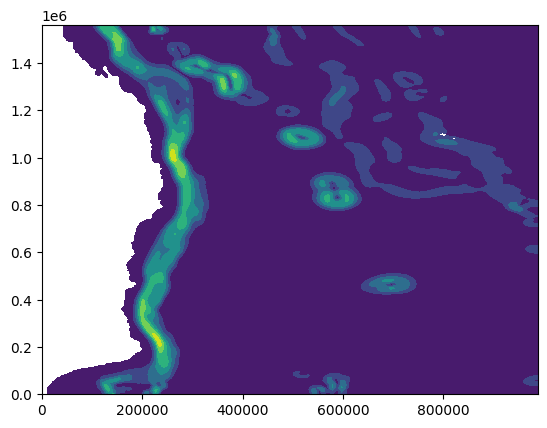

In [19]:
dhdx, dhdy = tilt.phys_grad(grid.h, grid.X_grid * 1e3, grid.Y_grid * 1e3, grid.mask_rho)
plt.contourf(grid.X_grid * 1e3, grid.Y_grid * 1e3, np.hypot(dhdx, dhdy))